## Clip a Wflow model

Let's imagine you have built and calibrated a **Wflow** model for a whole country or continent. And now you have a new project for a small basin belonging to your big calibrated Wflow model. Instead of re-building the smaller model from scratch with HydroMT and re-doing the calibration steps, you can easily use the **clip** method of HydroMT to directly extract your smaller catchment out of your already existing big calibrated model!

This notebook demonstrates how to clip a **Wflow** model from an already existing one using the ``update`` command line interace (CLI) and the **clip** method.

All lines in this notebook which start with `!` are executed from the command line. Within the notebook environment the logging messages are shown after completion. You can also copy these lines and paste these in your shell to get more direct feedback.

### Clip a small sub-basin

In order to clip a model, we need to prepare a configuration file using the **clip** method and specifying the region/basin to clip. Below you can see an example of such a file:

In [1]:
fn_config = "wflow_clip.yml"
with open(fn_config, "r") as f:
    txt = f.read()
print(txt)

global:
  config_filename: wflow_sbm.toml # name of the config file including paths to staticmaps / forcing / states to clip
steps:
  - clip: # clip method
      region: # region to clip
        subbasin: [12.3006, 46.4324] # derive a subbasin with its outlet at the given x,y coordinates
        meta_streamorder: 4 # snapped to a river with minimum stream order (strord) of 4
      inverse_clip: false # whether to clip the region (false) or the part outside of the region (true)
      clip_states: true # whether to clip the states or not
      clip_forcing: true # whether to clipt eh forcing or not



Now let's use the CLI to clip our model:

In [2]:
# NOTE: copy this line (without !) to your shell for more direct feedback
!hydromt update wflow_sbm "wflow_piave_subbasin" -o "./wflow_test_clip" -i wflow_clip.yml -v

2026-03-09 10:22:59,764 - hydromt - log - INFO - HydroMT version: 1.3.0
2026-03-09 10:22:59,828 - hydromt.model.model - model - INFO - Initializing wflow_sbm model from hydromt_wflow (v1.0.1).
2026-03-09 10:22:59,828 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from C:\Users\matti\miniconda3\envs\hydromt-wflow\Lib\site-packages\hydromt_wflow\data\parameters_data.yml
2026-03-09 10:22:59,878 - hydromt.hydromt_wflow.wflow_base - wflow_base - INFO - Supported Wflow.jl version v1+
2026-03-09 10:22:59,878 - hydromt.hydromt_wflow.components.config - config - INFO - Reading model config file from C:/Data/TUD/MSc_CE/Courses/2nd_year/7.CIE5060_Thesis/Codes/MSc_thesis_hydromt_wflow/examples/wflow_piave_subbasin/wflow_sbm.toml.
2026-03-09 10:22:59,880 - hydromt - log - INFO - HydroMT version: 1.3.0
2026-03-09 10:22:59,882 - hydromt.hydromt_wflow.components.config - config - INFO - Reading model config file from C:/Data/TUD/MSc_CE/Courses/2nd_year/7.CIE5060_Thesi

The example above means the following: run **hydromt clip** with:

* `wflow_sbm` : i.e. clip a wflow SBM model
* `wflow_piave_subbasin`: original model to clip
* -o `./wflow_test_clip` : output model folder
*  -i `wflow_clip.yml` : configuration file with settings for clipping (including the region).
* `-vv` : give some extra verbosity (2 * v) to display feedback on screen. Now debug messages are provided.

NOTE: Compared to build, you may notice here that the streamorder argument is called 'meta_streamorder'. As we are clipping a wflow model, the name here should correspond to the name of the stream order map inside of your wflow model staticmaps.

### Visualize and/or inspect model schematization

The **wflow plot** example notebook contains scripts to visualize your model.

Here we will just simply plot the region of the different model (original and clipped) to check the differences between them.

In [3]:
# Import plot packages
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt

# import descartes  # used under the hood to plot polygons

In [4]:
import numpy as np
from hydromt_wflow import WflowSbmModel

In [5]:
# Load both models with hydromt
mod0 = WflowSbmModel(root="wflow_piave_subbasin", mode="r")
mod1 = WflowSbmModel(root="wflow_test_clip", mode="r")

2026-03-09 10:24:18,422 - hydromt.model.model - model - INFO - Initializing wflow_sbm model from hydromt_wflow (v1.0.1).
2026-03-09 10:24:18,423 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from c:\Users\matti\miniconda3\envs\hydromt-wflow\Lib\site-packages\hydromt_wflow\data\parameters_data.yml
2026-03-09 10:24:18,486 - hydromt.hydromt_wflow.wflow_base - wflow_base - INFO - Supported Wflow.jl version v1+
2026-03-09 10:24:18,487 - hydromt.hydromt_wflow.components.config - config - INFO - Reading model config file from C:/Data/TUD/MSc_CE/Courses/2nd_year/7.CIE5060_Thesis/Codes/MSc_thesis_hydromt_wflow/examples/wflow_piave_subbasin/wflow_sbm.toml.
2026-03-09 10:24:18,490 - hydromt.model.model - model - INFO - Initializing wflow_sbm model from hydromt_wflow (v1.0.1).
2026-03-09 10:24:18,491 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from c:\Users\matti\miniconda3\envs\hydromt-wflow\Lib\site-packages\hydromt_wflow\da

In [6]:
# read/derive river geometries
gdf_riv0 = mod0.rivers
gdf_riv1 = mod1.rivers
# read/derive model basin boundary
gdf_bas0 = mod0.basins
gdf_bas1 = mod1.basins

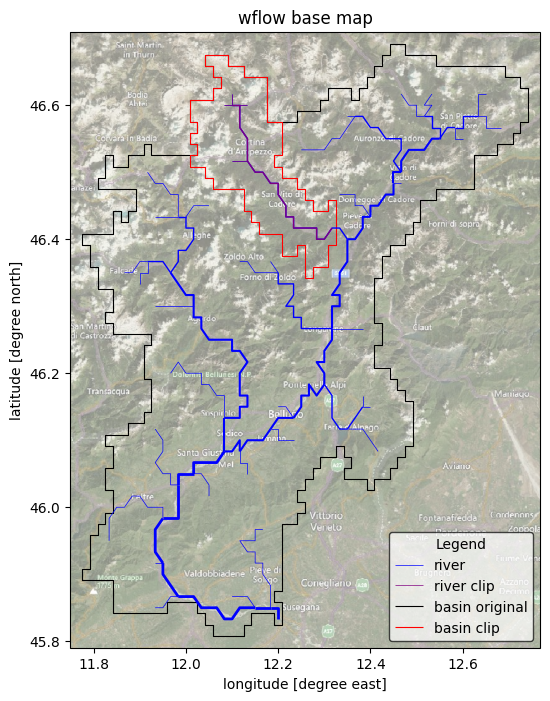

In [7]:
# we assume the model maps are in the geographic CRS EPSG:4326
proj = ccrs.PlateCarree()
# adjust zoomlevel and figure size to your basis size & aspect
zoom_level = 10
figsize = (10, 8)
shaded = False


# initialize image with geoaxes
fig = plt.figure(figsize=figsize)
ax = fig.add_subplot(projection=proj)
bounds = mod0.staticmaps.data.raster.box.to_crs(3847).buffer(2000).to_crs(4326).total_bounds
extent = np.array(bounds)[[0, 2, 1, 3]]
ax.set_extent(extent, crs=proj)

# add sat background image
ax.add_image(cimgt.QuadtreeTiles(), zoom_level, alpha=0.5)

# plot rivers with increasing width with stream order
gdf_riv0.plot(ax=ax, lw=gdf_riv0["strord"] / 2, color="blue", zorder=3, label="river")
gdf_riv1.plot(
    ax=ax, lw=gdf_riv1["strord"] / 2, color="purple", zorder=3, label="river clip"
)
# plot the basin boundary
gdf_bas0.boundary.plot(ax=ax, color="k", linewidth=0.8, label="basin original")
gdf_bas1.boundary.plot(ax=ax, color="r", linewidth=0.8, label="basin clip")

ax.xaxis.set_visible(True)
ax.yaxis.set_visible(True)
ax.set_ylabel(f"latitude [degree north]")
ax.set_xlabel(f"longitude [degree east]")
_ = ax.set_title(f"wflow base map")
legend = ax.legend(
    handles=[*ax.get_legend_handles_labels()[0]],
    title="Legend",
    loc="lower right",
    frameon=True,
    framealpha=0.7,
    edgecolor="k",
    facecolor="white",
)